<img src="./logo_UNSAM.png" align="right" width="150" /> 

# Trabajo Semanal Nº2

#### Nicolás Galván

# Introducción

En este trabajo práctico se aborda el estudio del proceso de digitalización de señales mediante una simulación numérica implementada en Python. En lugar de analizar un convertidor analógico-digital (ADC) físico, se modela su comportamiento a partir de operaciones matemáticas que representan el muestreo, la adición de ruido y la cuantización de una señal.

La señal de interés es una senoidal de energía normalizada generada mediante una función propia, a la cual se le agrega ruido gaussiano aditivo para simular condiciones no ideales de adquisición. Este ruido se controla a través de un parámetro que permite ajustar su potencia en relación con el ruido de cuantización, posibilitando el análisis de distintos escenarios.

El proceso de cuantización se implementa de manera discreta utilizando una resolución finita determinada por la cantidad de bits y un rango dinámico definido. A partir de esto, se obtiene una señal digitalizada cuya diferencia con la señal original permite estudiar el error de cuantización y sus características estadísticas.

Asimismo, se analiza el comportamiento de las señales tanto en el dominio temporal como en el espectral, utilizando la Transformada Rápida de Fourier (FFT) para observar la distribución de potencia y la aparición de pisos de ruido. También se estudia la distribución del error de cuantización mediante histogramas, verificando su correspondencia con los modelos teóricos.

Finalmente, se evalúa la influencia de los parámetros principales del sistema, como la cantidad de bits y el nivel de ruido agregado, permitiendo comprender los compromisos entre resolución, ruido y calidad de la señal digital obtenida.

## Ejercicio Nº1

### Item a

Llamo a las librerías a utilizar y defino mis variables que voy a implementar.

In [319]:
import numpy as np
import matplotlib.pyplot as plt

N   = 1000
fs  = 1000
df  = fs / N
B   = 4
Vfs = 2
kn  = 1
f0 = df                 
A  = np.sqrt(2)   

Cálculo el paso de cuantización.

In [320]:
qq = Vfs / (2**B)   


Cálculo la potencia del ruido de cuantización.

In [321]:
Pq = qq**2 / 12

Defino mi función seno.

In [322]:
def mi_funcion_sen(vmax=1, dc=0, ff=1, ph=0, nn=1000, fs=1000):
    tt = np.arange(0, nn) / fs
    velang = 2 * np.pi * ff
    xx = dc + vmax * np.sin(velang * tt + ph)
    return tt, xx

Se llama a la función pasándole como parámetros la amplitud máxima de la señal senoidal, la frecuencia, el número de muestras tomadas por el ADC y la frecuencia de muestreo del ADC.

In [323]:
tt, ss = mi_funcion_sen(vmax=A, ff=f0, nn=N, fs=fs)

Defino la potencia del ruido analógico.

In [324]:
Pn  = kn * Pq

Defino mi señal que entra al ADC.

In [325]:
nn  = np.random.normal(0, np.sqrt(Pn), N)
sR  = ss + nn

Defino mi señal cuantizada y el error de cuantización.

In [326]:
sQ = np.round(sR / qq) * qq

eq = sQ - sR

Defino mis pisos de ruido.

In [327]:
piso_anal_dB = 10 * np.log10(Pn / (N/2))
piso_dig_dB  = 10 * np.log10(Pq / (N/2))

Defino mi función de espectro en dB.

In [328]:
def espectro_uni_dB(x, N):
    X   = np.fft.fft(x) / N
    P   = np.abs(X)**2
    Pu  = P[:N//2 + 1].copy()
    Pu[1:-1] *= 2
    return 10 * np.log10(Pu + 1e-20) # 1e-20 para evitar log10(0)

Defino mi eje de frecuencia.

In [329]:
frec = np.arange(N//2 + 1) * df

Cálculo espectros de:
- salida ADC
- señal original
- señal con ruido

In [330]:
dB_sQ = espectro_uni_dB(sQ, N)
dB_ss = espectro_uni_dB(ss, N)
dB_sR = espectro_uni_dB(sR, N)

Se grafica la señal cuantizada, la señal con ruido y la señal original.

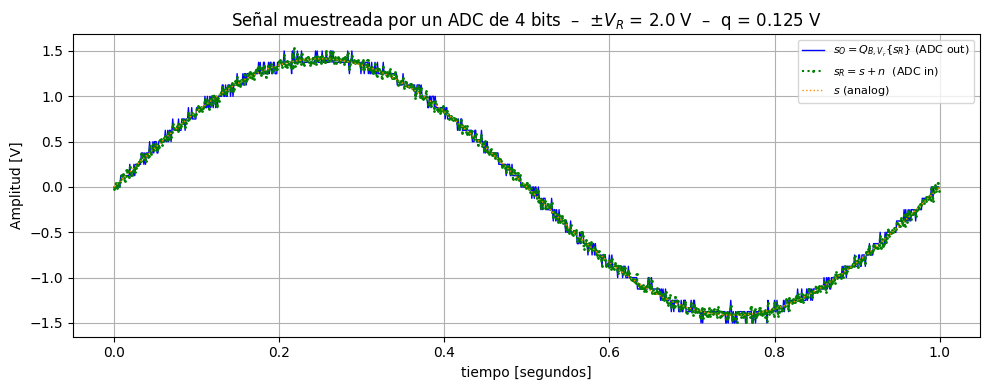

In [331]:
plt.figure(figsize=(10, 4))
plt.plot(tt, sQ,  color='blue',  lw=1,   label=r'$s_O = Q_{B,V_r}\{s_R\}$ (ADC out)')
plt.plot(tt, sR,  'g.',  ms=2, ls='dotted',   label=r'$s_R = s + n$  (ADC in)')
plt.plot(tt, ss,  color='darkorange', lw=1, ls='dotted', label=r'$s$ (analog)')
plt.xlabel('tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.title(f'Señal muestreada por un ADC de {B} bits  –  'f'$\\pm V_R$ = {Vfs:.1f} V  –  q = {qq:.3f} V')
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

Se grafica el espectro de la salida del ADC, el espectro de la señal original, el espectro de la señal con ruido, el piso de ruido analogico y el piso de ruido digital.

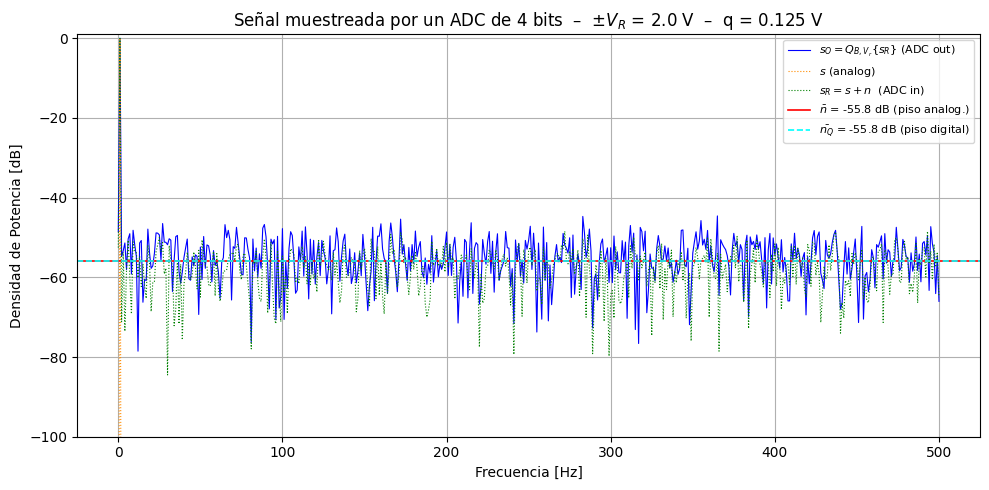

In [332]:
plt.figure(figsize=(10, 5))
plt.ylim(bottom=-100)
plt.plot(frec, dB_sQ, color='blue',  lw=0.8,label=r'$s_O = Q_{B,V_r}\{s_R\}$ (ADC out)')
plt.plot(frec, dB_ss, color='darkorange',  lw=0.8, ls='dotted', label=r'$s$ (analog)')
plt.plot(frec, dB_sR, color='green',      lw=0.8, ls='dotted', label=r'$s_R = s + n$  (ADC in)')

# Líneas horizontales de los pisos
plt.axhline(piso_anal_dB, color='red',  lw=1.2, ls='-', label=rf'$\bar{{n}}$ = {piso_anal_dB:.1f} dB (piso analog.)')
plt.axhline(piso_dig_dB,  color='cyan', lw=1.2, ls='--', label=rf'$\bar{{n_Q}}$ = {piso_dig_dB:.1f} dB (piso digital)')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de Potencia [dB]')
plt.title(f'Señal muestreada por un ADC de {B} bits  –  'f'$\\pm V_R$ = {Vfs:.1f} V  –  q = {qq:.3f} V')
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

Se grafica el histograma del error de cuantización.

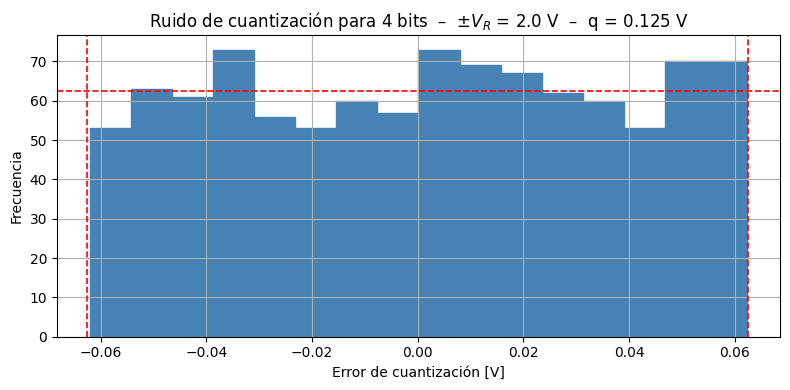

In [333]:
plt.figure(figsize=(8, 4))
plt.hist(eq, bins=16, color='steelblue', edgecolor='steelblue')

techo = N / 16         
x_izq = -qq / 2
x_der =  qq / 2

plt.axhline(techo, color='red', lw=1.2, ls='--')  
plt.axvline(x_izq, color='red', lw=1.2, ls='--')   
plt.axvline(x_der, color='red', lw=1.2, ls='--')    


plt.xlabel('Error de cuantización [V]')
plt.ylabel('Frecuencia')
plt.title(f'Ruido de cuantización para {B} bits  –  'f'$\\pm V_R$ = {Vfs:.1f} V  –  q = {qq:.3f} V')
plt.grid(True)
plt.tight_layout()
plt.show()


### Item b

Se realizó un nuevo análisis, pero con la siguiente configuración.

In [334]:
B   = 16
kn  = 10

Recalculó el paso de cuantización.

In [335]:
qq = Vfs / (2**B)   

Recalculó la potencia del ruido de cuantización.

In [336]:
Pq = qq**2 / 12

Recalculó la potencia del ruido analógico.

In [337]:
Pn  = kn * Pq

Se realiza un nuevo análisis mi señal que entra al ADC.

In [338]:
nn  = np.random.normal(0, np.sqrt(Pn), N)
sR  = ss + nn

Se redefinen la señal cuantizada y el error de cuantización.

In [339]:
sQ = np.round(sR / qq) * qq

eq = sQ - sR

Se redefinen los pisos de ruido.

In [340]:
piso_anal_dB = 10 * np.log10(Pn / (N/2))
piso_dig_dB  = 10 * np.log10(Pq / (N/2))

Recalculó espectros de:
- salida ADC
- señal original
- señal con ruido

In [341]:
dB_sQ = espectro_uni_dB(sQ, N)
dB_ss = espectro_uni_dB(ss, N)
dB_sR = espectro_uni_dB(sR, N)

Se grafica la nueva señal cuantizada, la nueva señal con ruido y la señal original.

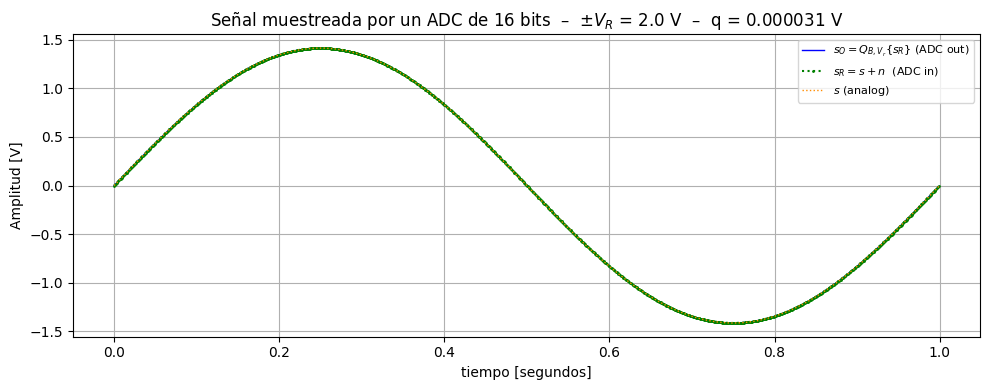

In [342]:
plt.figure(figsize=(10, 4))
plt.plot(tt, sQ,  color='blue',  lw=1,   label=r'$s_O = Q_{B,V_r}\{s_R\}$ (ADC out)')
plt.plot(tt, sR,  'g.',  ms=2, ls='dotted',   label=r'$s_R = s + n$  (ADC in)')
plt.plot(tt, ss,  color='darkorange', lw=1, ls='dotted', label=r'$s$ (analog)')
plt.xlabel('tiempo [segundos]')
plt.ylabel('Amplitud [V]')
plt.title(f'Señal muestreada por un ADC de {B} bits  –  'f'$\\pm V_R$ = {Vfs:.1f} V  –  q = {qq:.6f} V')
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

Se generan nuevamente las gráficas del espectro de la salida del ADC, el espectro de la señal original, el espectro de la señal con ruido, el piso de ruido analogico y el piso de ruido digital.

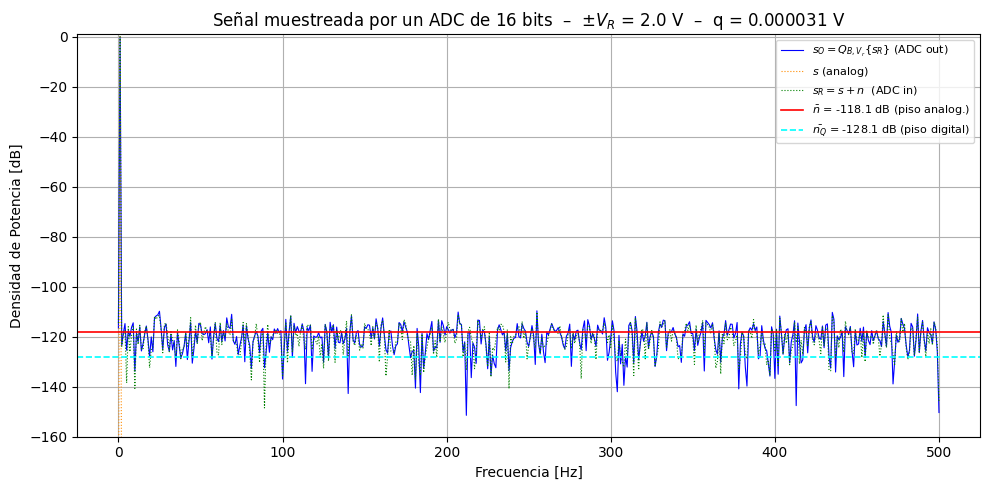

In [343]:
plt.figure(figsize=(10, 5))
plt.ylim(bottom=-160)
plt.plot(frec, dB_sQ, color='blue',  lw=0.8,label=r'$s_O = Q_{B,V_r}\{s_R\}$ (ADC out)')
plt.plot(frec, dB_ss, color='darkorange',  lw=0.8, ls='dotted', label=r'$s$ (analog)')
plt.plot(frec, dB_sR, color='green',      lw=0.8, ls='dotted', label=r'$s_R = s + n$  (ADC in)')

# Líneas horizontales de los pisos
plt.axhline(piso_anal_dB, color='red',  lw=1.2, ls='-', label=rf'$\bar{{n}}$ = {piso_anal_dB:.1f} dB (piso analog.)')
plt.axhline(piso_dig_dB,  color='cyan', lw=1.2, ls='--', label=rf'$\bar{{n_Q}}$ = {piso_dig_dB:.1f} dB (piso digital)')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Densidad de Potencia [dB]')
plt.title(f'Señal muestreada por un ADC de {B} bits  –  'f'$\\pm V_R$ = {Vfs:.1f} V  –  q = {qq:.6f} V')
plt.legend(fontsize=8)
plt.grid(True)
plt.tight_layout()
plt.show()

Se vuelve a graficar el histograma del error de cuantización.

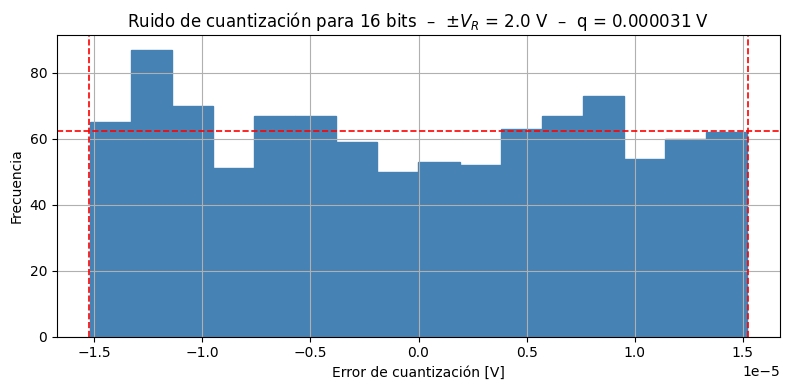

In [344]:
plt.figure(figsize=(8, 4))
plt.hist(eq, bins=16, color='steelblue', edgecolor='steelblue')

techo = N / 16          
x_izq = -qq / 2
x_der =  qq / 2

plt.axhline(techo, color='red', lw=1.2, ls='--')   
plt.axvline(x_izq, color='red', lw=1.2, ls='--')   
plt.axvline(x_der, color='red', lw=1.2, ls='--')   


plt.xlabel('Error de cuantización [V]')
plt.ylabel('Frecuencia')
plt.title(f'Ruido de cuantización para {B} bits  –  'f'$\\pm V_R$ = {Vfs:.1f} V  –  q = {qq:.6f} V')
plt.grid(True)
plt.tight_layout()
plt.show()

# Análisis de Resultados
## Temporal
Se comparan los resultados obtenidos para dos configuraciones del sistema: por un lado, B = 4 bits y $k_n$ = 1, y por otro, B = 16 bits y $k_n$ = 10.

Para el caso de B = 4 y $k_n$ = 1, la señal de salida del ADC presenta una degradación moderada. Esto se debe a que el ruido de cuantización es significativo (debido a la baja resolución) y, al mismo tiempo, el ruido analógico tiene una potencia comparable. En el dominio temporal se observa una señal escalonada con dispersión alrededor de la senoidal ideal, evidenciando la presencia simultánea de ambos efectos.

En contraste, para la configuración B = 16 bits y $k_n$ = 10, la situación cambia notablemente. El aumento en la cantidad de bits reduce considerablemente el paso de cuantización, haciendo que el error de cuantización sea prácticamente despreciable. Como resultado, la señal cuantizada ($s_Q$) sigue muy de cerca a la señal de entrada ($s_R$), sin presentar escalonamientos visibles.

Sin embargo, al incrementarse el factor $k_n$, la potencia del ruido analógico se vuelve dominante. Esto implica que, aunque el ADC tenga una alta resolución, la calidad final de la señal está limitada principalmente por el ruido presente en la entrada. En otras palabras, la mejora en la cuantización no se traduce en una mejora proporcional en la señal final, ya que el ruido analógico enmascara cualquier beneficio adicional.

Comparando ambas configuraciones, se observa que:
- En el primer caso B = 4, $k_n$ = 1, la limitación está dada tanto por la cuantización como por el ruido.
- En el segundo caso B = 16, $k_n$ = 10, la limitación está dominada por el ruido analógico.

Respecto a lo obtenido en el apartado anterior, estos resultados evidencian el compromiso fundamental en sistemas de adquisición: aumentar la resolución del ADC solo es útil si el nivel de ruido analógico es suficientemente bajo. De lo contrario, el sistema queda limitado por el ruido de entrada y no por la cuantización.

En conclusión, el análisis conjunto muestra que no siempre incrementar la cantidad de bits mejora el desempeño global, sino que es necesario considerar simultáneamente el nivel de ruido presente en la señal para optimizar el sistema.

---

## Espectro

Para la configuración B = 16 bits y $k_n$ = 10, se observa un comportamiento significativamente distinto respecto al caso analizado en el apartado a) B = 4 y $k_n$ = 1.

En el dominio temporal, la señal cuantizada ($s_Q$) prácticamente coincide con la señal de entrada ($s_R = s + n$), sin evidenciarse escalonamientos visibles. Esto se debe a que el paso de cuantización es extremadamente pequeño ($q \approx 3.05 \times 10^{-5}$ V), lo que hace que el error de cuantización sea despreciable frente a otras fuentes de error. En consecuencia, el ADC simulado reproduce con gran fidelidad la señal de entrada.

Sin embargo, a diferencia del caso a), el ruido analógico tiene una influencia dominante. Dado que $k_n$ = 10, la potencia del ruido agregado es diez veces mayor que la del ruido de cuantización. Esto se refleja en una mayor dispersión de la señal respecto a la senoidal ideal, siendo esta variabilidad completamente atribuible al ruido analógico.

En el dominio espectral, esta situación se manifiesta en un piso de ruido analógico elevado, mientras que el piso de ruido de cuantización se encuentra varios decibeles por debajo, resultando prácticamente imperceptible. Esto confirma que el sistema ya no está limitado por la resolución del ADC, sino por el ruido presente en la señal de entrada.

Comparando con el caso del apartado a):
- En B = 4 y $k_n$ = 1, tanto el ruido de cuantización como el analógico contribuyen de manera similar a la degradación de la señal.
- En B = 16 y $k_n$ = 10, el ruido de cuantización es despreciable y el desempeño del sistema está completamente dominado por el ruido analógico.

En conclusión, aumentar la cantidad de bits mejora la precisión del proceso de cuantización, pero esta mejora deja de ser relevante cuando el nivel de ruido analógico es elevado. Esto evidencia que la calidad final del sistema no depende únicamente de la resolución del ADC, sino también de las condiciones de la señal de entrada.

---

## Ruido de cuantización

Se analiza la distribución del error de cuantización para dos configuraciones: B = 4 bits con $k_n$ = 1 (caso a) y B = 16 bits con $k_n$ = 10.

En ambos casos, el histograma del error de cuantización presenta una forma aproximadamente uniforme dentro del intervalo $-q/2$ y $q/2$, lo cual coincide con el modelo teórico del ruido de cuantización. Esto indica que el error puede considerarse una variable aleatoria uniforme, no correlacionada con la señal de entrada.

Para el caso de B = 4 bits, el paso de cuantización es relativamente grande ($q = 0.125 V$), por lo que el rango del error también es amplio. Esto se refleja en un histograma extendido, donde las variaciones del error tienen un impacto significativo sobre la señal cuantizada. En este escenario, el ruido de cuantización es una fuente importante de degradación y resulta comparable con el ruido analógico.

En contraste, para B = 16 bits, el paso de cuantización es extremadamente pequeño ($q \approx 3.05 \times 10^{-5}$ V), lo que reduce drásticamente el rango del error. El histograma sigue siendo uniforme, pero se encuentra concentrado en un intervalo muy reducido alrededor de cero. Esto implica que el error de cuantización es prácticamente despreciable en términos absolutos.

Comparando ambos casos, se observa que:
- La forma de la distribución del error no cambia (permanece uniforme), validando el modelo teórico.
- La amplitud del error depende directamente del paso de cuantización ($q$), el cual disminuye al aumentar la cantidad de bits.
- En el caso de alta resolución B = 16, el ruido de cuantización pierde relevancia frente al ruido analógico, especialmente cuando este último es elevado ($k_n$ = 10).

En relación con el apartado a), se concluye que mientras en B = 4 el error de cuantización tiene un rol importante en la degradación de la señal, en B = 16 su influencia es prácticamente nula. Esto refuerza la idea de que, en sistemas con alta resolución, la calidad final está limitada principalmente por el ruido analógico y no por la cuantización.

# Bonus

## SNR en conversores ADC

El SNR en decibelios para un conversor de $N$ bits se expresa mediante la siguiente ecuación:

$$SNR = 6.02N + 10.79 + 20\log_{10}\left(\frac{\sigma_x}{V_{FS}}\right)$$

Esta fórmula muestra que el SNR depende de tres factores críticos:

- **La resolución ($N$):** Al aumentar el número de bits, se reduce el tamaño del
escalón de cuantización ($\Delta V$), lo que disminuye la potencia del ruido de
cuantización y aumenta el SNR.

- **El nivel de la señal ($\sigma_x$):** Representa el valor eficaz (rms) de la señal de
entrada. Cuanto mayor sea este nivel, mejor será el SNR.

- **El rango de escala completa ($V_{FS}$):** Es el rango total de voltaje que el ADC
puede manejar. Si la señal es pequeña comparada con este rango, el SNR
disminuye debido a que el término logarítmico se vuelve más negativo.

### Regla de oro

En el cálculo del SNR
para una **onda senoidal** que ocupa todo el rango del conversor. El resultado es la
conocida **"regla de oro"**:

$$SNR = 6.02N + 1.76 \text{ dB}$$

### Autoevaluación del aprendisaje

A lo largo de este trabajo práctico se logró profundizar en la comprensión del proceso de digitalización de señales mediante un ADC, incorporando no solo el efecto de la cuantización sino también el impacto del muestreo y del ruido analógico aditivo. En relación con los objetivos planteados en la introducción, se pudo verificar cómo una señal senoidal de energía normalizada se ve afectada por estos fenómenos, tanto en el dominio temporal como en el espectral.

En una primera instancia (apartado a), se implementó el modelo completo del ADC con una configuración de referencia (B = 4 bits y k_n = 1). Esto permitió observar claramente la presencia del ruido de cuantización, la discretización en amplitud de la señal y la aparición de pisos de ruido bien definidos en el espectro. Asimismo, el histograma del error de cuantización evidenció una distribución aproximadamente uniforme, en concordancia con el modelo teórico.

En una segunda etapa, se analizó el comportamiento del sistema al modificar los parámetros del ADC y del ruido analógico, considerando distintas configuraciones de resolución y niveles de ruido, en nuestro caso B = 16 bits y k_n = 10. Este análisis permitió extraer las siguientes conclusiones:

- Al aumentar la cantidad de bits, disminuye el paso de cuantización, reduciendo así la potencia del ruido de cuantización. Esto se traduce en una mejora significativa en la calidad de la señal digital y en una disminución del piso de ruido digital en el espectro.
- Para valores bajos de k_n, el ruido analógico es despreciable frente al de cuantización, por lo que el desempeño del sistema está limitado principalmente por la resolución del ADC.
- Para valores altos de k_n, el ruido analógico domina, elevando el piso de ruido total y enmascarando los beneficios de aumentar la cantidad de bits.
- Existe un compromiso entre resolución y nivel de ruido: incrementar B más allá de cierto punto no produce mejoras apreciables si el ruido analógico es elevado.

En comparación con los resultados obtenidos en el apartado a), se pudo observar que dicha configuración representa un caso intermedio donde ambos tipos de ruido tienen contribuciones similares. Esto permitió utilizarla como referencia para evaluar cómo varía el sistema al modificar cada parámetro de manera independiente.

En conclusión, este trabajo permitió no solo implementar un modelo funcional de un ADC, sino también interpretar sus limitaciones prácticas y comprender la relación entre cuantización, ruido y calidad de señal, aspectos fundamentales en sistemas de adquisición y procesamiento digital. En particular, el análisis del SNR permite cuantificar de manera directa estos efectos, evidenciando que la resolución del conversor tiene un impacto lineal en dB (aproximadamente 6 dB por bit), mientras que el nivel de la señal y su aprovechamiento del rango completo del ADC resultan igualmente determinantes. De este modo, se concluye que maximizar el SNR no depende únicamente de aumentar la cantidad de bits, sino de lograr un adecuado ajuste entre resolución, nivel de señal y rango dinámico, evitando tanto la subutilización del conversor como la dominancia del ruido analógico.